Experiment 3: Data Visualization Techniques
Course: CSDL8013 Applied Data Science Lab
Dataset: Online Payments Fraud Detection
Objective: To explore and visualize data using various graphical techniques
to identify patterns, trends, and anomalies.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [5]:
df = pd.read_csv("data/online_fraud.csv")
# df = df.sample(n=100000, random_state=42)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)


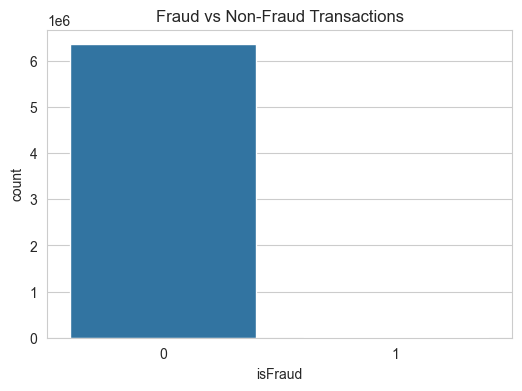

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


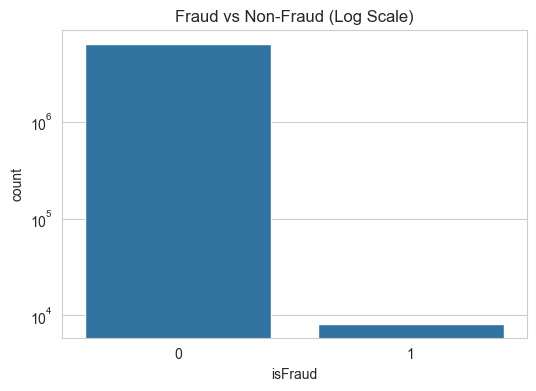

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.yscale('log')
plt.title("Fraud vs Non-Fraud (Log Scale)")
plt.show()


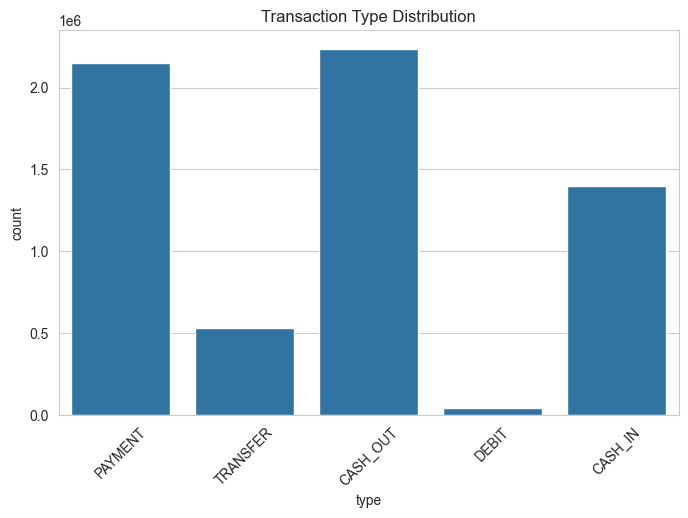

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.show()


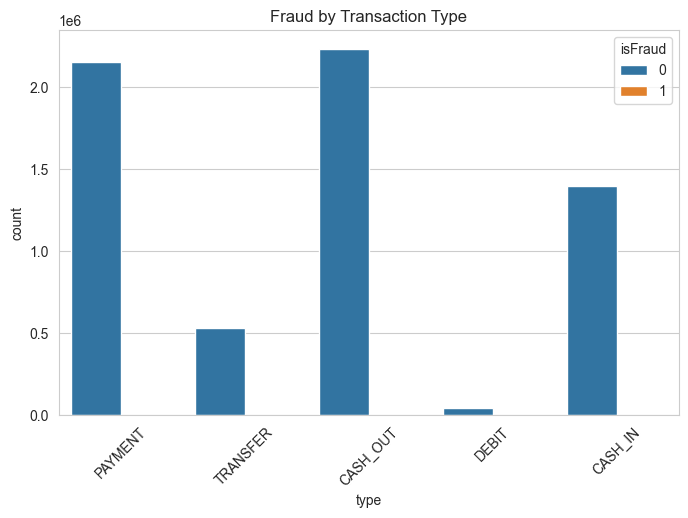

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()


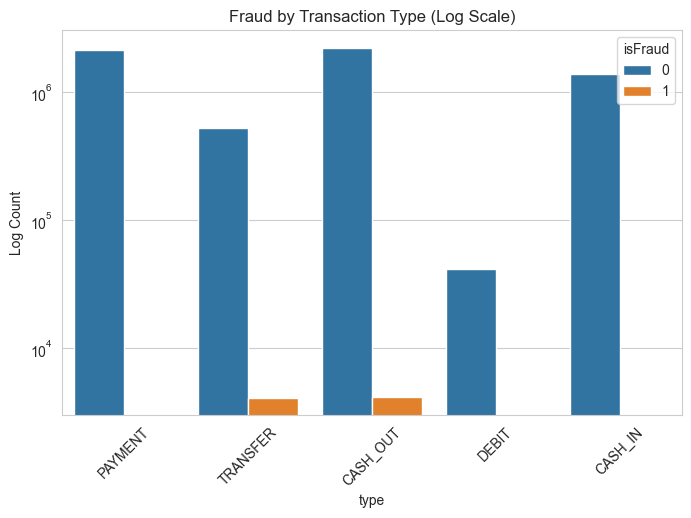

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.yscale('log')
plt.title("Fraud by Transaction Type (Log Scale)")
plt.xticks(rotation=45)
plt.ylabel("Log Count")
plt.show()


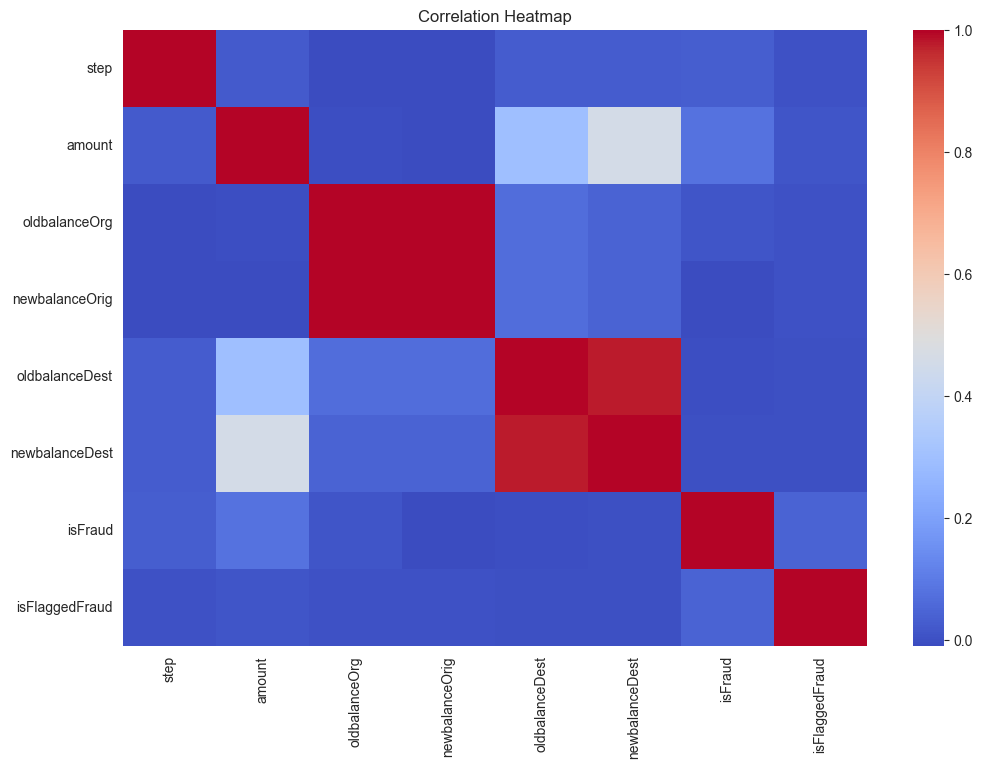

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


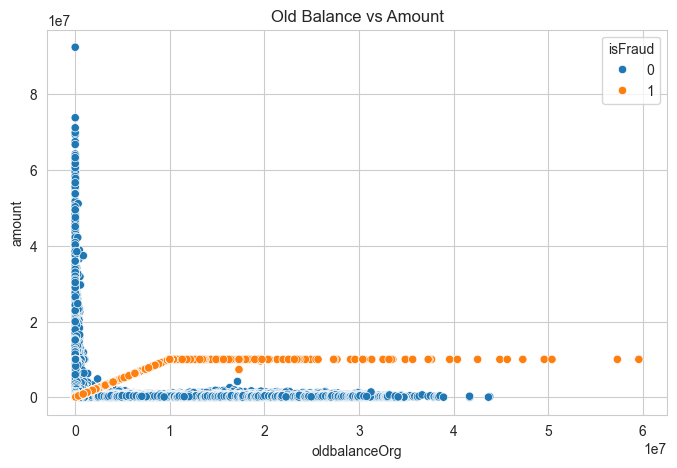

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='oldbalanceOrg', y='amount', hue='isFraud', data=df)
plt.title("Old Balance vs Amount")
plt.show()


Fraud transactions initially follow a linear pattern where the transaction amount equals the sender’s original balance, indicating account draining behavior. However, for higher balances, the amount appears capped, forming a horizontal pattern. This suggests dataset-level constraints in fraud transaction generation

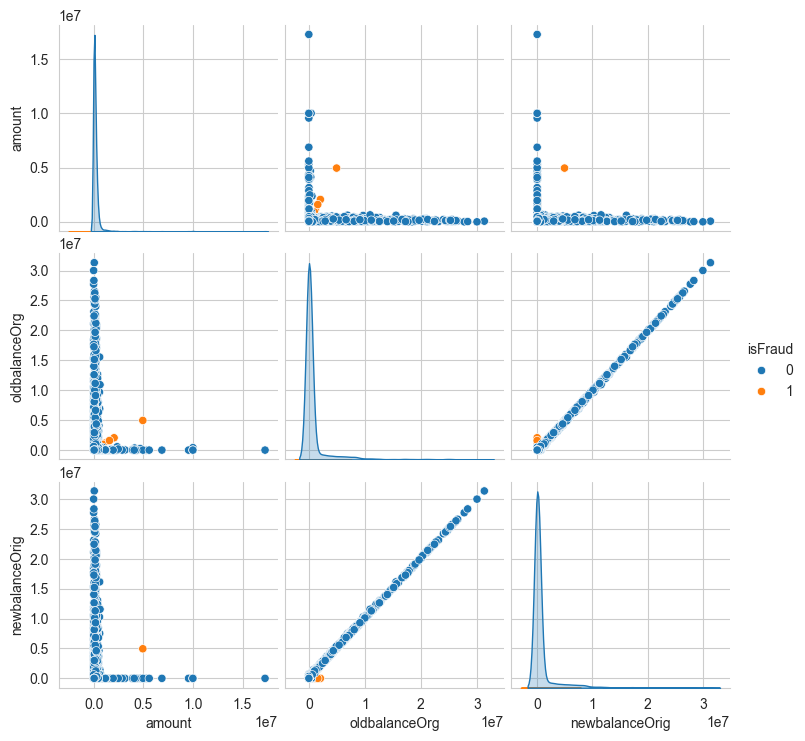

In [19]:
small_df = df.sample(5000, random_state=42)

sns.pairplot(small_df[['amount','oldbalanceOrg',
                       'newbalanceOrig','isFraud']],
             hue='isFraud')
plt.show()


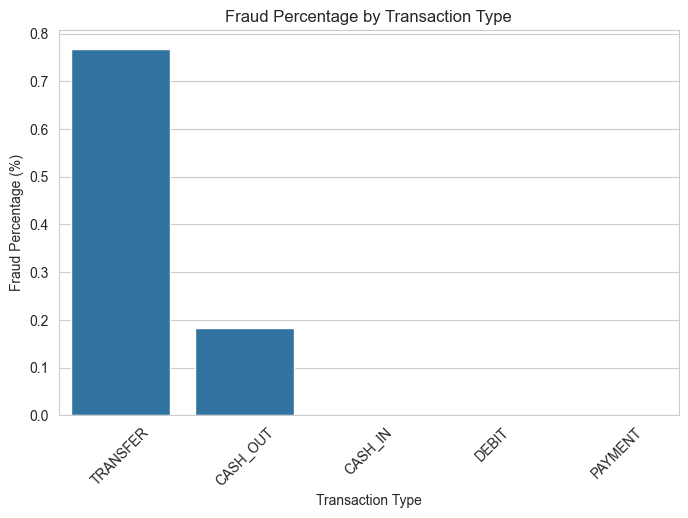

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate fraud percentage per type
fraud_rate = (
    df.groupby('type')['isFraud']
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
plt.title("Fraud Percentage by Transaction Type")
plt.ylabel("Fraud Percentage (%)")
plt.xlabel("Transaction Type")
plt.xticks(rotation=45)
plt.show()


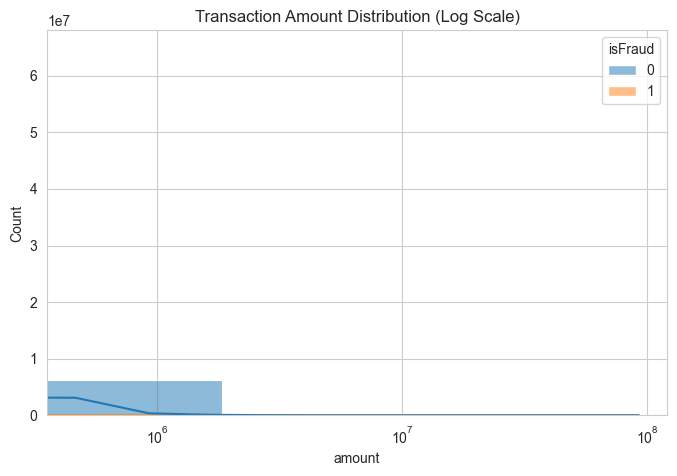

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='amount', hue='isFraud', bins=50, kde=True)
plt.xscale('log')
plt.title("Transaction Amount Distribution (Log Scale)")
plt.show()


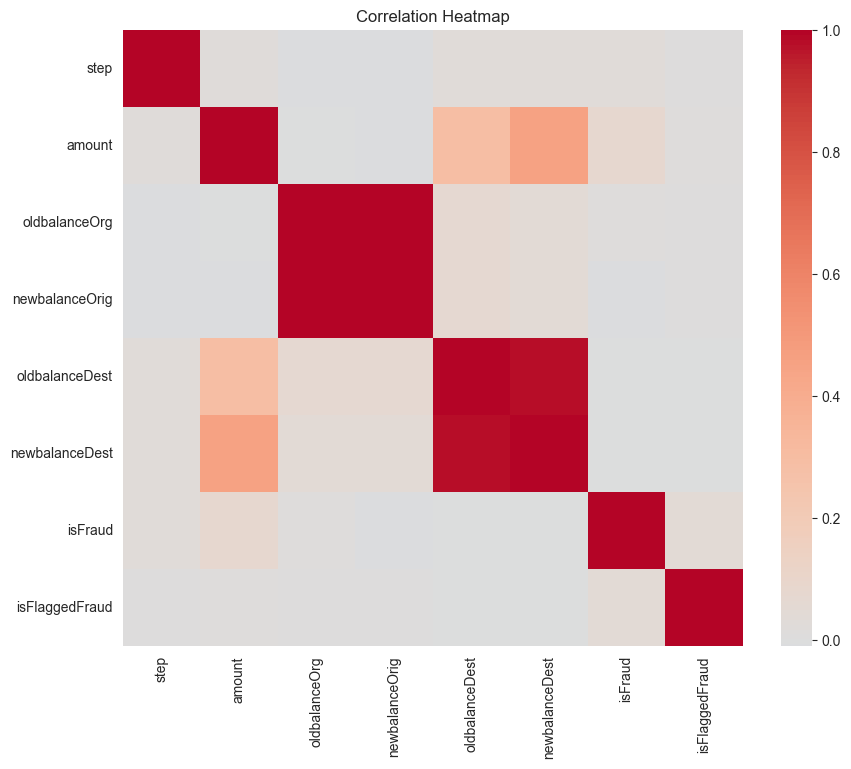

In [22]:
plt.figure(figsize=(10,8))

numeric_cols = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_cols.corr(), 
            annot=False, 
            cmap='coolwarm',
            center=0)

plt.title("Correlation Heatmap")
plt.show()


In [23]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


In [24]:
df_sample = df.sample(5000, random_state=42)


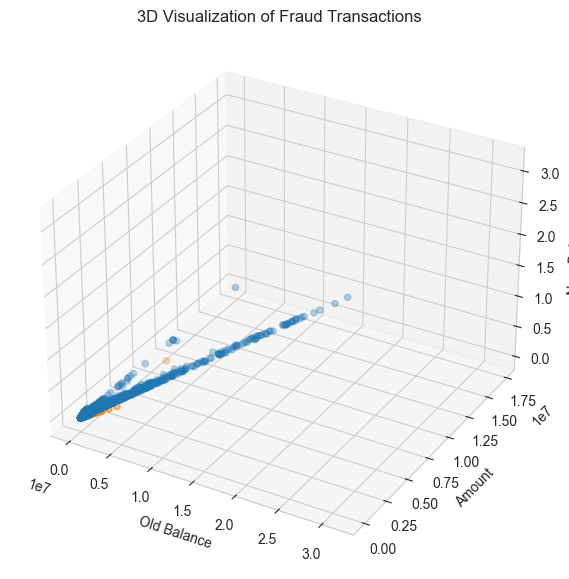

In [25]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Separate fraud and non-fraud
fraud = df_sample[df_sample['isFraud'] == 1]
non_fraud = df_sample[df_sample['isFraud'] == 0]

# Plot non-fraud
ax.scatter(non_fraud['oldbalanceOrg'],
           non_fraud['amount'],
           non_fraud['newbalanceOrig'],
           alpha=0.3)

# Plot fraud
ax.scatter(fraud['oldbalanceOrg'],
           fraud['amount'],
           fraud['newbalanceOrig'])

ax.set_xlabel('Old Balance')
ax.set_ylabel('Amount')
ax.set_zlabel('New Balance')
ax.set_title("3D Visualization of Fraud Transactions")

plt.show()


In [26]:
!pip install plotly


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 3.8 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.9 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.9 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.9 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 3.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 3.7 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 3.9 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.9 MB 4.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import plotly.io as pio
pio.renderers.default = "browser"

In [36]:
import plotly.express as px
df_sample = df.sample(4000, random_state=42)
fig = px.scatter_3d(
    df_sample,
    x='oldbalanceOrg',
    y='amount',
    z='newbalanceOrig',
    color='isFraud',
    opacity=0.6,
    title="Interactive 3D Fraud Visualization"
)

fig.show()
